## LiDAR Terrain Corrections
### This notebook is predominantly derived from the harmonica topographic corrections model

#### Members: Molly Bilhartz, Samantha Lopez, Tessa Murphy

In [3]:
import os

os.environ["PROJ_DATA"] = "/opt/homebrew/Caskroom/miniconda/base/envs/gpgn-318/share/proj"
os.environ["PROJ_LIB"] = "/opt/homebrew/Caskroom/miniconda/base/envs/gpgn-318/share/proj"

from pyproj import datadir
datadir.set_data_dir(os.environ["PROJ_DATA"])

from pyproj import CRS, Transformer
print(CRS.from_epsg(4326))
print(Transformer.from_crs("EPSG:4326", "EPSG:26913", always_xy=True))

EPSG:4326
unavailable until proj_trans is called


In [4]:
from pathlib import Path
import sys

# Current location:
# Project/notebooks/WORKING
PROJECT = Path.cwd().parents[1]

PY_DIR = PROJECT / "notebooks" / "PY files"

GRAVITY_DIR = PROJECT / "data" / "gravity"
LIDAR_DIR = PROJECT / "data" / "LiDAR"

sys.path.append(str(PY_DIR))

import onyx_harmonica_lidar_terrain_correction as tc

# --------------------------------------------------
# INPUT FILES
# --------------------------------------------------

tc.GRAVITY_CSV = GRAVITY_DIR / "Onyx_Gravity_Final_Bouguer_Corrected.csv"

tc.GPS_CSV = GRAVITY_DIR / "raw_data" / "gps_data" / "gps_points_with_elevation.csv"

# New LiDAR folder shown in GitHub
LIDAR_TILE_DIR = LIDAR_DIR / "LiDAR_2026-06-05T19_40_33.076Z"

# Automatically grab every .tif file in that folder
tc.DEM_TILES = sorted(LIDAR_TILE_DIR.glob("*.tif"))

print(f"Found {len(tc.DEM_TILES)} DEM tiles:")
for tile in tc.DEM_TILES:
    print(tile.name)

# Safety check
if len(tc.DEM_TILES) == 0:
    raise FileNotFoundError(f"No .tif files found in: {LIDAR_TILE_DIR}")

# --------------------------------------------------
# OUTPUT FILES
# --------------------------------------------------

tc.OUT_CSV = GRAVITY_DIR / "Onyx_Gravity_Harmonica_LiDAR_Terrain_Corrected.csv"

tc.OUT_DEM = LIDAR_DIR / "Onyx_Merged_DEM_UTM13N.tif"

# --------------------------------------------------
# MODEL PARAMETERS
# --------------------------------------------------

tc.DST_CRS = "EPSG:26913"

# DEM is in US Survey Feet
tc.DEM_Z_FACTOR = 0.30480060960121924

tc.MODEL_SPACING_M = 5.0
tc.PAD_M = 500.0

# Sandstone-like density
tc.DENSITY_KG_M3 = 2670.0

tc.UPWARD_OFFSET_M = 0.25

Found 21 DEM tiles:
LD26171415.tif
LD26171418.tif
LD26171421.tif
LD26171424.tif
LD26171427.tif
LD26201415.tif
LD26201418.tif
LD26201421.tif
LD26201424.tif
LD26201427.tif
LD26231415.tif
LD26231418.tif
LD26231421.tif
LD26231424.tif
LD26261415.tif
LD26261418.tif
LD26261421.tif
LD26261424.tif
LD26291415.tif
LD26291418.tif
LD26291421.tif


In [5]:
gravity = tc.load_and_prepare_gravity()

topo, gravity_projected = tc.merge_crop_reproject_dem(gravity)

print("Station easting range:")
print(gravity_projected["easting_m"].min(), gravity_projected["easting_m"].max())

print("Station northing range:")
print(gravity_projected["northing_m"].min(), gravity_projected["northing_m"].max())

print("DEM easting range:")
print(float(topo.easting.min()), float(topo.easting.max()))

print("DEM northing range:")
print(float(topo.northing.min()), float(topo.northing.max()))

Station easting range:
344413.82448802976 344418.05885412626
Station northing range:
4482504.652252167 4482531.999133004
DEM easting range:
343916.32448802976 344916.32448802976
DEM northing range:
4482004.499133004 4483029.499133004


In [6]:
gravity.head()

,station,gravity_final_mgal,elevation_m,latitude,longitude,free_air_correction_mgal,bouguer_correction_mgal,gravity_tied_mgal,instrument,gps_longitude,gps_latitude,gps_elevation_m
0,1.0,0.589314,2112.468,40.478666,-106.835495,0.803286,0.291414,0.077442,CG5-2,-106.835495,40.478666,2112.468
1,2.0,0.423992,2112.006,40.478675,-106.835498,0.660713,0.239692,0.002971,CG5-2,-106.835498,40.478675,2112.006
2,3.0,0.423230,2111.569,40.478684,-106.835500,0.525854,0.190768,0.088144,CG5-2,-106.835500,40.478684,2111.569
3,4.0,0.458692,2111.692,40.478692,-106.835503,0.563812,0.204538,0.099418,CG5-2,-106.835503,40.478692,2111.692
4,5.0,0.507517,2111.862,40.478702,-106.835504,0.616274,0.223570,0.114813,CG5-2,-106.835504,40.478702,2111.862


In [7]:
topo, gravity_projected = tc.merge_crop_reproject_dem(gravity)

print(topo)
gravity_projected.head()

<xarray.DataArray 'topography' (northing: 206, easting: 201)> Size: 166kB
array([[2212.5996, 2212.6663, 2212.5613, ..., 2050.922 , 2050.9705,
        2050.9368],
       [2211.867 , 2211.7388, 2211.6763, ..., 2050.9797, 2050.941 ,
        2050.9622],
       [2211.33  , 2211.0635, 2210.8132, ..., 2050.9932, 2050.9885,
        2050.9517],
       ...,
       [2122.3748, 2121.1775, 2119.9185, ..., 2051.3013, 2051.3848,
        2051.6116],
       [2121.2708, 2119.9014, 2118.7415, ..., 2051.3962, 2051.6772,
        2052.0156],
       [2119.9192, 2118.5059, 2117.207 , ..., 2051.7046, 2052.0317,
        2052.1345]], shape=(206, 201), dtype=float32)
Coordinates:
  * northing  (northing) float64 2kB 4.482e+06 4.482e+06 ... 4.483e+06 4.483e+06
  * easting   (easting) float64 2kB 3.439e+05 3.439e+05 ... 3.449e+05 3.449e+05
Attributes:
    units:        m
    crs:          EPSG:26913
    description:  LiDAR DEM reprojected to meters


,station,gravity_final_mgal,elevation_m,latitude,longitude,free_air_correction_mgal,bouguer_correction_mgal,gravity_tied_mgal,instrument,gps_longitude,gps_latitude,gps_elevation_m,easting_m,northing_m
0,1.0,0.589314,2112.468,40.478666,-106.835495,0.803286,0.291414,0.077442,CG5-2,-106.835495,40.478666,2112.468,344418.058854,4.482505e+06
1,2.0,0.423992,2112.006,40.478675,-106.835498,0.660713,0.239692,0.002971,CG5-2,-106.835498,40.478675,2112.006,344417.830475,4.482506e+06
2,3.0,0.423230,2111.569,40.478684,-106.835500,0.525854,0.190768,0.088144,CG5-2,-106.835500,40.478684,2111.569,344417.640938,4.482507e+06
3,4.0,0.458692,2111.692,40.478692,-106.835503,0.563812,0.204538,0.099418,CG5-2,-106.835503,40.478692,2111.692,344417.436458,4.482508e+06
4,5.0,0.507517,2111.862,40.478702,-106.835504,0.616274,0.223570,0.114813,CG5-2,-106.835504,40.478702,2111.862,344417.349965,4.482509e+06


In [8]:
out = tc.compute_harmonica_terrain_correction(gravity_projected, topo)
out.head()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,station,gravity_final_mgal,elevation_m,latitude,longitude,free_air_correction_mgal,bouguer_correction_mgal,gravity_tied_mgal,instrument,gps_longitude,gps_latitude,gps_elevation_m,easting_m,northing_m,dem_elevation_m_at_station,obs_height_used_m,harmonica_topography_effect_mgal,gravity_harmonica_lidar_corrected_mgal,harmonica_minus_simple_bouguer_mgal,simple_bouguer_minus_harmonica_effect_mgal
0,1.0,0.589314,2112.468,40.478666,-106.835495,0.803286,0.291414,0.077442,CG5-2,-106.835495,40.478666,2112.468,344418.058854,4.482505e+06,2124.461284,2124.711284,1.699904,-0.819176,-1.408490,-1.408490
1,2.0,0.423992,2112.006,40.478675,-106.835498,0.660713,0.239692,0.002971,CG5-2,-106.835498,40.478675,2112.006,344417.830475,4.482506e+06,2124.390225,2124.640225,1.700923,-1.037240,-1.461231,-1.461231
2,3.0,0.423230,2111.569,40.478684,-106.835500,0.525854,0.190768,0.088144,CG5-2,-106.835500,40.478684,2111.569,344417.640938,4.482507e+06,2124.322714,2124.572714,1.696373,-1.082375,-1.505605,-1.505605
3,4.0,0.458692,2111.692,40.478692,-106.835503,0.563812,0.204538,0.099418,CG5-2,-106.835503,40.478692,2111.692,344417.436458,4.482508e+06,2124.256692,2124.506692,1.661811,-0.998581,-1.457273,-1.457273
4,5.0,0.507517,2111.862,40.478702,-106.835504,0.616274,0.223570,0.114813,CG5-2,-106.835504,40.478702,2111.862,344417.349965,4.482509e+06,2124.173364,2124.423364,1.659828,-0.928741,-1.436258,-1.436258


In [9]:
# out.to_csv(tc.OUT_CSV, index=False)
# print("Saved:", tc.OUT_CSV)

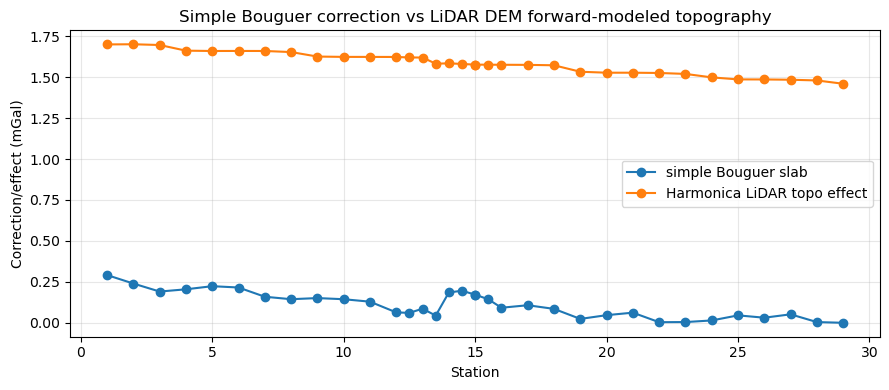

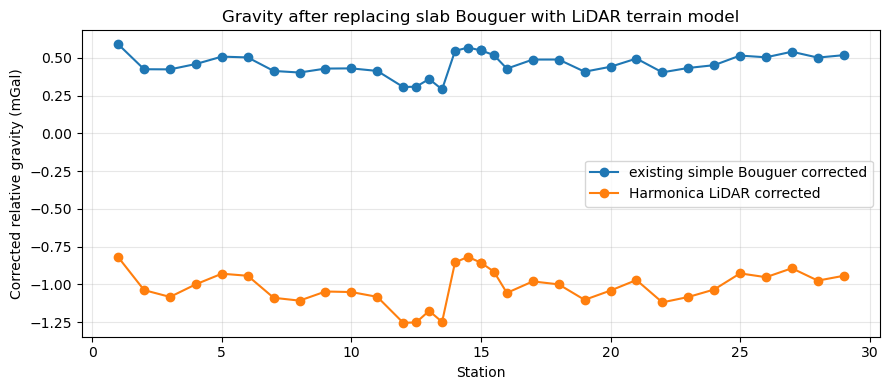

In [10]:
tc.plot_qc(out)

In [11]:
def plot_qc_demeaned(out):
    import matplotlib.pyplot as plt

    x = out["station"]

    boug = out["bouguer_correction_mgal"]
    topo = out["harmonica_topography_effect_mgal"]

    plt.figure(figsize=(10, 5))
    plt.plot(x, boug - boug.mean(), "o-", label="Simple Bouguer slab, demeaned")
    plt.plot(x, topo - topo.mean(), "o-", label="LiDAR topo effect, demeaned")
    plt.axhline(0, color="k", linewidth=0.8)
    plt.xlabel("Station")
    plt.ylabel("Demeaned correction/effect (mGal)")
    plt.title("Correction shape comparison after removing mean offset")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

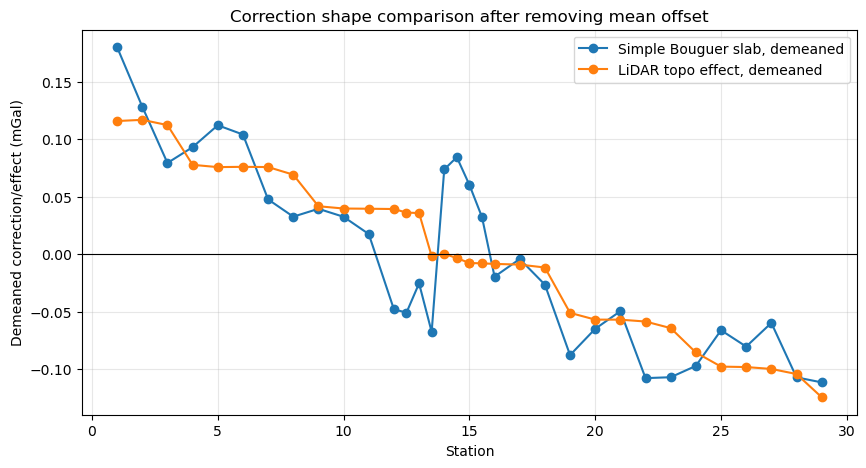

In [12]:
plot_qc_demeaned(out)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [14]:
def elevation_control_analysis(out):
    df = out.copy()

    # Pick best available elevation column
    if "dem_elevation_m_at_station" in df.columns:
        elev_col = "dem_elevation_m_at_station"
    else:
        elev_col = "elevation_m"

    gravity_cols = [
        "gravity_final_mgal",
        "gravity_harmonica_lidar_corrected_mgal",
        "harmonica_topography_effect_mgal",
        "bouguer_correction_mgal",
    ]

    gravity_cols = [c for c in gravity_cols if c in df.columns]

    print("Using elevation column:", elev_col)
    print("\nElevation-control statistics:")

    results = []

    for col in gravity_cols:
        temp = df[[elev_col, col]].dropna()

        x = temp[elev_col].values.reshape(-1, 1)
        y = temp[col].values

        model = LinearRegression()
        model.fit(x, y)

        y_pred = model.predict(x)
        r2 = r2_score(y, y_pred)
        r, p = pearsonr(temp[elev_col], temp[col])

        results.append({
            "gravity_column": col,
            "slope_mGal_per_m": model.coef_[0],
            "intercept_mGal": model.intercept_,
            "R2": r2,
            "pearson_r": r,
            "p_value": p,
        })

    results_df = pd.DataFrame(results)
    display(results_df)

    return results_df

In [15]:
elev_results = elevation_control_analysis(out)

Using elevation column: dem_elevation_m_at_station

Elevation-control statistics:


,gravity_column,slope_mGal_per_m,intercept_mGal,R2,pearson_r,p_value
0,gravity_final_mgal,-0.020466,43.914659,0.032409,-0.180025,3.082939e-01
1,gravity_harmonica_lidar_corrected_mgal,-0.020063,41.588131,0.012498,-0.111794,5.290468e-01
2,harmonica_topography_effect_mgal,0.103944,-219.129019,0.979435,0.989664,1.446636e-28
3,bouguer_correction_mgal,0.104347,-221.455546,0.733940,0.856703,1.019300e-10


In [16]:
def plot_gravity_vs_elevation(out):
    df = out.copy()

    if "dem_elevation_m_at_station" in df.columns:
        elev_col = "dem_elevation_m_at_station"
    else:
        elev_col = "elevation_m"

    gravity_cols = [
        "gravity_final_mgal",
        "gravity_harmonica_lidar_corrected_mgal",
    ]

    gravity_cols = [c for c in gravity_cols if c in df.columns]

    for col in gravity_cols:
        temp = df[[elev_col, col, "station"]].dropna()

        x = temp[elev_col].values.reshape(-1, 1)
        y = temp[col].values

        model = LinearRegression()
        model.fit(x, y)
        y_pred = model.predict(x)

        plt.figure(figsize=(8, 5))
        plt.scatter(temp[elev_col], y, label=col)
        plt.plot(temp[elev_col], y_pred, label=f"linear fit, R²={r2_score(y, y_pred):.3f}")
        plt.xlabel("Elevation at station (m)")
        plt.ylabel("Gravity / residual gravity (mGal)")
        plt.title(f"{col} vs elevation")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

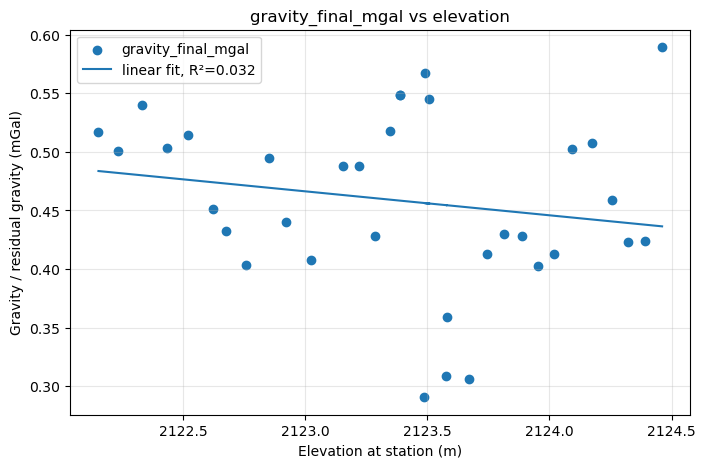

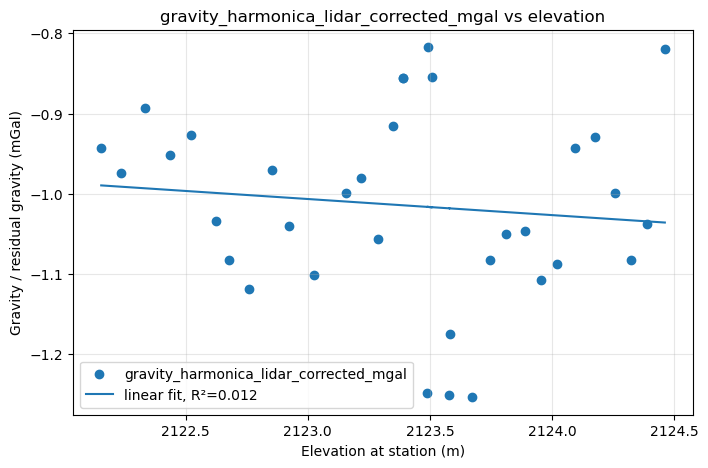

In [17]:
plot_gravity_vs_elevation(out)

In [18]:
def remove_elevation_trend(out):
    df = out.copy()

    if "dem_elevation_m_at_station" in df.columns:
        elev_col = "dem_elevation_m_at_station"
    else:
        elev_col = "elevation_m"

    target_cols = [
        "gravity_final_mgal",
        "gravity_harmonica_lidar_corrected_mgal",
    ]

    target_cols = [c for c in target_cols if c in df.columns]

    for col in target_cols:
        temp = df[[elev_col, col]].dropna()

        x = temp[elev_col].values.reshape(-1, 1)
        y = temp[col].values

        model = LinearRegression()
        model.fit(x, y)

        trend = model.predict(df[[elev_col]].values.reshape(-1, 1))
        df[col + "_elevation_trend_mgal"] = trend
        df[col + "_elevation_removed_mgal"] = df[col] - trend

    return df

In [19]:
out_elev_removed = remove_elevation_trend(out)

In [20]:
def plot_elevation_removed_profiles(df):
    x = df["station"]

    cols = [
        "gravity_final_mgal_elevation_removed_mgal",
        "gravity_harmonica_lidar_corrected_mgal_elevation_removed_mgal",
    ]

    cols = [c for c in cols if c in df.columns]

    plt.figure(figsize=(10, 5))

    for col in cols:
        plt.plot(x, df[col] - df[col].mean(), "o-", label=col)

    plt.axhline(0, color="k", linewidth=0.8)
    plt.xlabel("Station")
    plt.ylabel("Elevation-removed residual gravity, demeaned (mGal)")
    plt.title("Residual gravity after removing linear elevation control")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

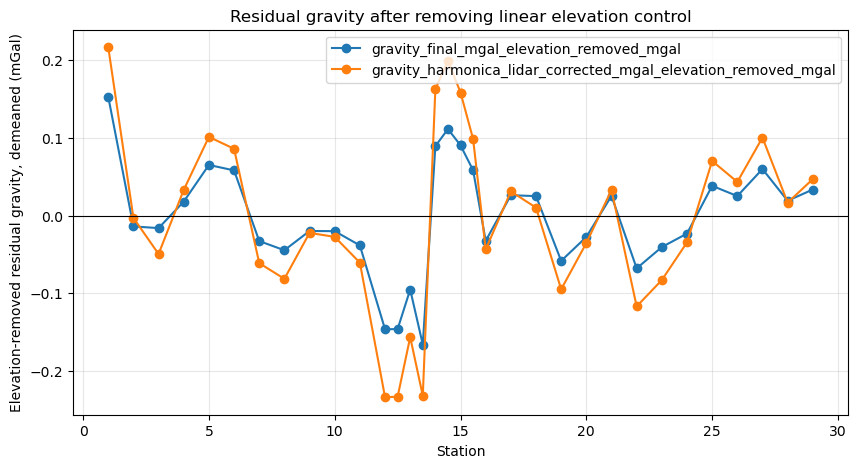

In [21]:
plot_elevation_removed_profiles(out_elev_removed)

In [23]:
def plot_elevation_and_gravity_profiles(out):
    df = out.copy()

    if "dem_elevation_m_at_station" in df.columns:
        elev_col = "dem_elevation_m_at_station"
    else:
        elev_col = "elevation_m"

    x = df["station"]

    plt.figure(figsize=(10, 5))
    plt.plot(x, df[elev_col] - df[elev_col].mean(), "o-", label="Elevation, demeaned")

    if "gravity_final_mgal" in df.columns:
        plt.plot(x, df["gravity_final_mgal"] - df["gravity_final_mgal"].mean(), "o-", label="Simple Bouguer gravity, demeaned")

    if "gravity_harmonica_lidar_corrected_mgal" in df.columns:
        plt.plot(x, df["gravity_harmonica_lidar_corrected_mgal"] - df["gravity_harmonica_lidar_corrected_mgal"].mean(), "o-", label="LiDAR-corrected gravity, demeaned")

    plt.axhline(0, color="k", linewidth=0.8)
    plt.xlabel("Station")
    plt.ylabel("Demeaned value")
    plt.title("Elevation shape compared with corrected gravity shape")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

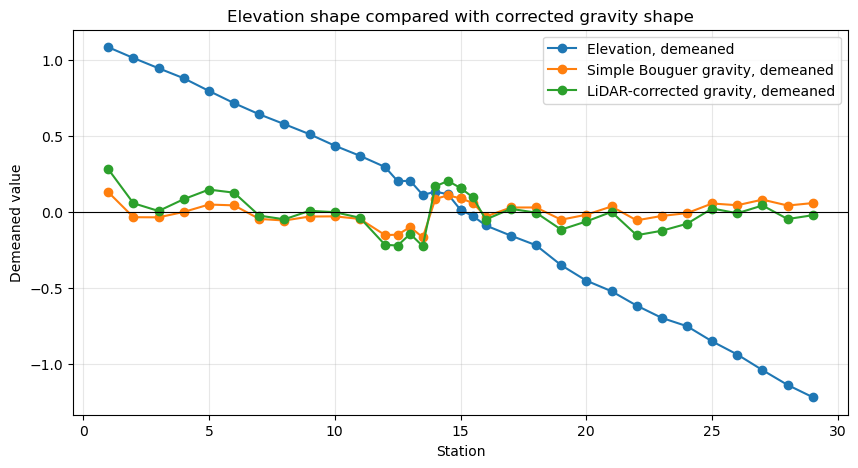

In [24]:
plot_elevation_and_gravity_profiles(out)